# 图像分辨率 × Think cap × 蒸馏步数:延迟三维 sweep(最终实验)

在 `think_cap_benchmark` 已确立的两条线性定律基础上,加入第三个自变量——**图像分辨率 R**:

- 已知:`t_think ≈ 0.055·T`(与 N 无关);`t_image ≈ 0.53·N` @1024(与 cap 无关)
- 图像 token 数 = `(R / 16)²`(VAE 8× 下采样 × latent_patch 2×);R=1024 → 4096 token
- **R 上限就是 1024**(`max_latent_size = 64`),只能向下扫;边长须为 16 的倍数

## 假设

| # | 假设 | 检验方式 |
|---|------|---------|
| H1 | `t_image(N, R) = s(R)·N`,对 N 线性在所有 R 下成立 | §5 分组线性拟合,看截距≈0、R² |
| H2 | `s(R) ≈ a + b·tok(R)`(+ 可能的二次项 c·tok²,来自 attention) | §6 线性 vs 二次拟合对比 |
| H3 | t2i 无图像输入,`t_think` 应与 R **完全无关**(计时自检) | §8 Kruskal-Wallis,预期不显著 |

推论:`ratio ≈ 0.055·T / (s(R)·N)`,平衡点 `T* ≈ s(R)·N / 0.055` —— 分辨率越低,think 越容易成为瓶颈。

## 网格

R ∈ {1024, 768, 512, 256} × N ∈ {50, 10, 5} × cap ∈ {1000, 256, 128, 64, 32}
= 60 conditions × 16 prompts × 2 repeats = **1920 trials**(4 workers × 2 GPU,预计 ~2h)

> 执行侧复用已验证的多卡架构(`experiments/run_res_sweep_mp.py`,
> 与 `run_cap_sweep_mp.py` 同构:subprocess + CUDA_VISIBLE_DEVICES + 手动均衡 device_map)。
> 本 notebook 只负责启动 sweep 和分析结果,内核本身不加载模型。


## 1. 环境 / import

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, kruskal

# 允许从 repo root 或 experiments/ 目录启动
if os.path.basename(os.getcwd()) == "experiments":
    os.chdir("..")

OUTPUT_DIR = "experiments/think_res_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

LATENT_DOWNSAMPLE = 16
IMAGE_SIDE_LIST = [1024, 768, 512, 256]
NUM_TIMESTEPS_LIST = [50, 10, 5]
MAX_THINK_TOKEN_LIST = [1000, 256, 128, 64, 32]

print("cwd:", os.getcwd())


## 2. 多卡并行 sweep(launcher)

启动 `run_res_sweep_mp.py`(4 workers × 2 GPU)。**如果 `think_res_outputs/trials.csv` 已存在,
这个 cell 会跳过运行直接进入 §3**;想强制重跑就把 `FORCE_RERUN = True`。

In [ ]:
import subprocess, sys

FORCE_RERUN = False
merged_path = os.path.join(OUTPUT_DIR, "trials.csv")

if os.path.exists(merged_path) and not FORCE_RERUN:
    print(f"{merged_path} 已存在,跳过 sweep(FORCE_RERUN=True 可强制重跑)")
else:
    print("启动多卡并行 sweep (4 workers × 2 GPU)...")
    result = subprocess.run(
        [sys.executable, "experiments/run_res_sweep_mp.py",
         "--gpus", "0,1,2,3,4,5,6,7",
         "--gpus-per-worker", "2"],
        cwd=os.getcwd(),
        capture_output=False,  # 实时输出进度
    )
    if result.returncode == 0:
        print("\n多卡 sweep 完成!")
    else:
        print(f"\n多卡 sweep 失败 (exit code {result.returncode}),检查终端输出")


## 3. 加载结果 + 派生指标

In [11]:
df = pd.read_csv(os.path.join(OUTPUT_DIR, "trials.csv"))
print(f"Loaded {len(df)} rows | OK: {df['ok'].sum()} | Failed: {(~df['ok']).sum()}")

ok = df[df["ok"]].copy()
ok["ratio_think_image"] = ok["t_think"] / ok["t_image"]
ok["fraction_think"] = ok["t_think"] / (ok["t_think"] + ok["t_image"])
# image_token_count worker 已记录;兜底重算一次保证列存在
if "image_token_count" not in ok.columns:
    ok["image_token_count"] = (ok["image_side"] // LATENT_DOWNSAMPLE) ** 2

print("\n每个 (R, N, cap) 组合的试次数:")
print(ok.groupby(["image_side", "num_timesteps", "max_think_token_n"]).size().describe())


Loaded 1920 rows | OK: 1920 | Failed: 0

每个 (R, N, cap) 组合的试次数:
count    60.0
mean     32.0
std       0.0
min      32.0
25%      32.0
50%      32.0
75%      32.0
max      32.0
dtype: float64


In [12]:
# ── 3b. 合并 budget forcing 补跑批次(如果存在)──
# 首跑时 FORCE_THINK_LENGTH=False,自然 think 长度只有 ~160 token,
# 所以 cap=256(部分)和 cap=1000(严重)并没有真正跑到 cap,
# §7 的 ratio/parity 图在高 cap 档失真。cap≤128 本来就被截断钉死,数据有效。
#
# 补救:在远程机器上用 forcing 只补跑这两档(24 conditions × 32 = 768 trials):
#   python experiments/run_res_sweep_mp.py --gpus 0,1,2,3,4,5,6,7 \
#       --force-think --caps 1000,256 \
#       --output-dir experiments/think_res_outputs_forced
# 补跑结果存在时,下面用强制批次整体替换 cap∈{256,1000} 的行。
FORCED_CAPS = [1000, 256]
forced_csv = os.path.join(OUTPUT_DIR + "_forced", "trials.csv")

if os.path.exists(forced_csv):
    fdf = pd.read_csv(forced_csv)
    fok = fdf[fdf["ok"]].copy()
    fok["ratio_think_image"] = fok["t_think"] / fok["t_image"]
    fok["fraction_think"] = fok["t_think"] / (fok["t_think"] + fok["t_image"])
    if "image_token_count" not in fok.columns:
        fok["image_token_count"] = (fok["image_side"] // LATENT_DOWNSAMPLE) ** 2

    n_dropped = ok["max_think_token_n"].isin(FORCED_CAPS).sum()
    ok = pd.concat(
        [ok[~ok["max_think_token_n"].isin(FORCED_CAPS)],
         fok[fok["max_think_token_n"].isin(FORCED_CAPS)]],
        ignore_index=True,
    )
    print(f"已合并 forcing 补跑批次: 替换 cap∈{FORCED_CAPS} 的 {n_dropped} 行 → "
          f"新增 {fok['max_think_token_n'].isin(FORCED_CAPS).sum()} 行, 合计 {len(ok)} 行")
    print("补跑批次 think 实际长度:")
    print(fok.groupby("max_think_token_n")["think_token_count"].describe()[["mean", "min", "max"]])
else:
    print(f"未发现 forcing 补跑数据 ({forced_csv})。")
    print("注意: cap=256/1000 档 think 实际只有 ~160 token, §7 的 ratio 图高 cap 档失真;")
    print("H1/H2/H3(分辨率相关结论)不受影响。补跑命令见本 cell 顶部注释。")


已合并 forcing 补跑批次: 替换 cap∈[1000, 256] 的 768 行 → 新增 768 行, 合计 1920 行
补跑批次 think 实际长度:
                    mean    min    max
max_think_token_n                     
256                255.0  255.0  255.0
1000               999.0  999.0  999.0


## 4. 聚合表(60 行:R × N × cap)

In [13]:
agg = (
    ok.groupby(["image_side", "num_timesteps", "max_think_token_n"])
    .agg(
        t_think_mean=("t_think", "mean"), t_think_std=("t_think", "std"),
        t_image_mean=("t_image", "mean"), t_image_std=("t_image", "std"),
        ratio_mean=("ratio_think_image", "mean"),
        fraction_think_mean=("fraction_think", "mean"),
        think_token_count_mean=("think_token_count", "mean"),
        image_token_count=("image_token_count", "first"),
        hit_cap_rate=("hit_cap", "mean"),
        think_closed_rate=("think_closed", "mean"),
        n=("t_think", "count"),
    )
    .reset_index()
    .sort_values(["image_side", "num_timesteps", "max_think_token_n"],
                 ascending=[False, False, False])
)
agg.to_csv(os.path.join(OUTPUT_DIR, "aggregated.csv"), index=False)
agg


,image_side,num_timesteps,max_think_token_n,t_think_mean,t_think_std,t_image_mean,t_image_std,ratio_mean,fraction_think_mean,think_token_count_mean,image_token_count,hit_cap_rate,think_closed_rate,n
59,1024,50,1000,55.101489,0.544503,26.974396,0.329357,2.042957,0.671347,999.0,4096,1.0,0.0,32
58,1024,50,256,14.037206,0.137779,26.502181,0.377817,0.529730,0.346278,255.0,4096,1.0,0.0,32
57,1024,50,128,7.085067,0.069498,26.498459,0.352068,0.267438,0.210993,127.0,4096,1.0,0.0,32
56,1024,50,64,3.526898,0.028717,26.425911,0.314436,0.133489,0.117765,63.0,4096,1.0,0.0,32
55,1024,50,32,1.759688,0.020515,26.525472,0.322925,0.066354,0.062224,31.0,4096,1.0,0.0,32
54,1024,10,1000,55.038486,0.612947,5.243040,0.103309,10.500467,0.913023,999.0,4096,1.0,0.0,32
53,1024,10,256,14.050901,0.169259,5.119137,0.073716,2.745204,0.732956,255.0,4096,1.0,0.0,32
52,1024,10,128,7.048253,0.066534,5.109207,0.076723,1.379878,0.579756,127.0,4096,1.0,0.0,32
51,1024,10,64,3.519064,0.024813,5.132264,0.092118,0.685909,0.406807,63.0,4096,1.0,0.0,32
50,1024,10,32,1.758638,0.020900,5.129023,0.081619,0.342999,0.255369,31.0,4096,1.0,0.0,32


## 5. H1:`t_image = s(R)·N` —— 分组线性拟合

对每个 R,用 trial 级数据拟合 `t_image ~ N`。预期:截距 ≈ 0、R² 接近 1,
且斜率与 cap 无关(cap 只影响 think 段)。

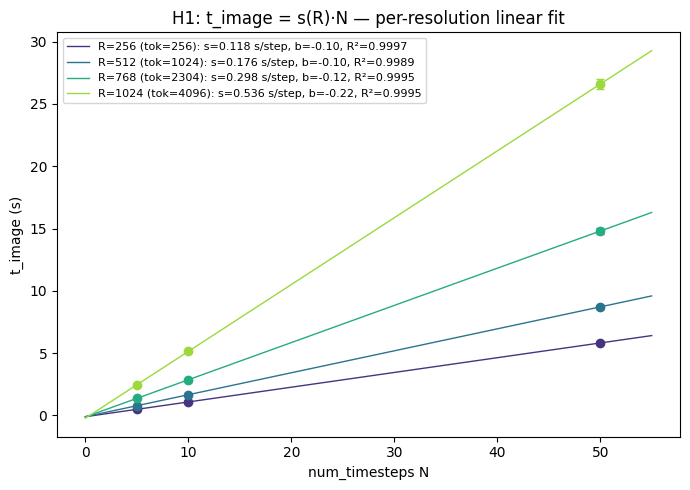

,image_side,image_tokens,s_per_step,intercept,r2,n
3,1024,4096,0.536111,-0.219678,0.999533,480
2,768,2304,0.298293,-0.119107,0.999478,480
1,512,1024,0.176180,-0.097800,0.998933,480
0,256,256,0.118336,-0.099148,0.999687,480


In [14]:
fit_rows = []
fig, ax = plt.subplots(figsize=(7, 5))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(IMAGE_SIDE_LIST)))

for color, side in zip(colors, sorted(IMAGE_SIDE_LIST)):
    sub = ok[ok["image_side"] == side]
    x, y = sub["num_timesteps"].values, sub["t_image"].values
    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept
    ss_res = ((y - y_pred) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    tok = (side // LATENT_DOWNSAMPLE) ** 2
    fit_rows.append(dict(image_side=side, image_tokens=tok,
                         s_per_step=slope, intercept=intercept, r2=r2, n=len(sub)))

    means = sub.groupby("num_timesteps")["t_image"].agg(["mean", "std"]).reset_index()
    ax.errorbar(means["num_timesteps"], means["mean"], yerr=means["std"],
                marker="o", linestyle="none", color=color, capsize=3)
    xs = np.linspace(0, 55, 10)
    ax.plot(xs, slope * xs + intercept, color=color, linewidth=1,
            label=f"R={side} (tok={tok}): s={slope:.3f} s/step, b={intercept:.2f}, R²={r2:.4f}")

ax.set_xlabel("num_timesteps N"); ax.set_ylabel("t_image (s)")
ax.set_title("H1: t_image = s(R)·N — per-resolution linear fit")
ax.legend(fontsize=8); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "t_image_vs_N_per_R.png"), dpi=150)
plt.show()

fit_df = pd.DataFrame(fit_rows).sort_values("image_side", ascending=False)
fit_df


## 6. H2(核心图):每步成本 `s(R)` vs 图像 token 数

用 §5 得到的 4 个斜率拟合 `s = a + b·tok`(线性)与 `s = a + b·tok + c·tok²`(二次)。
二次项显著 → attention 的平方复杂度可见;截距 a → 每步固定开销
(它解释了低分辨率为什么"不成比例地贵")。注:只有 4 个点,二次拟合自由度=1,结论定性看待。

线性:  s = 0.0718 + 1.096e-04·tok            RSS=1.317e-03
二次:  s = 0.1032 + 5.842e-05·tok + 1.153e-08·tok²  RSS=2.010e-06
外推检验: 线性模型下 s(tok→0) = 0.0718 s/step (每步固定开销)


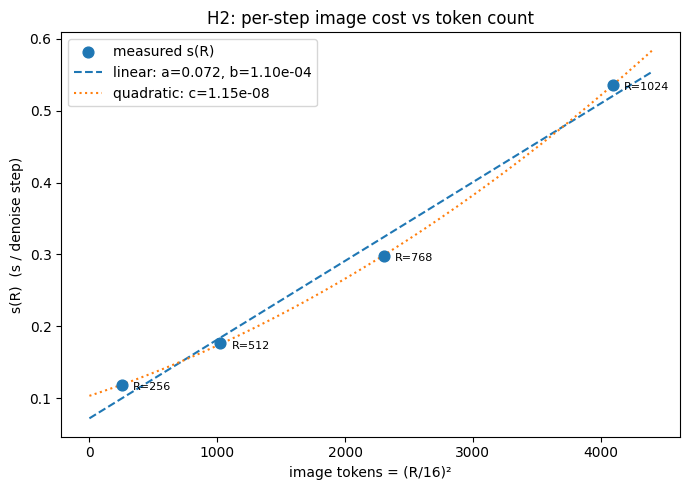

In [15]:
toks = fit_df["image_tokens"].values.astype(float)
s_vals = fit_df["s_per_step"].values

lin = np.polyfit(toks, s_vals, 1)        # [b, a]
quad = np.polyfit(toks, s_vals, 2)       # [c, b, a]
lin_resid = s_vals - np.polyval(lin, toks)
quad_resid = s_vals - np.polyval(quad, toks)

print(f"线性:  s = {lin[1]:.4f} + {lin[0]:.3e}·tok            RSS={np.sum(lin_resid**2):.3e}")
print(f"二次:  s = {quad[2]:.4f} + {quad[1]:.3e}·tok + {quad[0]:.3e}·tok²  RSS={np.sum(quad_resid**2):.3e}")
print(f"外推检验: 线性模型下 s(tok→0) = {lin[1]:.4f} s/step (每步固定开销)")

fig, ax = plt.subplots(figsize=(7, 5))
xs = np.linspace(0, 4400, 200)
ax.scatter(toks, s_vals, s=60, zorder=3, label="measured s(R)")
for t, s, side in zip(toks, s_vals, fit_df["image_side"]):
    ax.annotate(f"R={side}", (t, s), textcoords="offset points", xytext=(8, -4), fontsize=8)
ax.plot(xs, np.polyval(lin, xs), "--", label=f"linear: a={lin[1]:.3f}, b={lin[0]:.2e}")
ax.plot(xs, np.polyval(quad, xs), ":", label=f"quadratic: c={quad[0]:.2e}")
ax.set_xlabel("image tokens = (R/16)²"); ax.set_ylabel("s(R)  (s / denoise step)")
ax.set_title("H2: per-step image cost vs token count")
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "s_vs_tokens.png"), dpi=150)
plt.show()


## 7. ratio / fraction_think 全景

左:每个 R 一个面板,ratio vs cap(log-log,虚线 = parity);右:fraction_think 热力图按 R 分面。
预期:R 越小面板整体越"红"(think 占比越高),平衡点 `T* ≈ s(R)·N / 0.055` 左移。

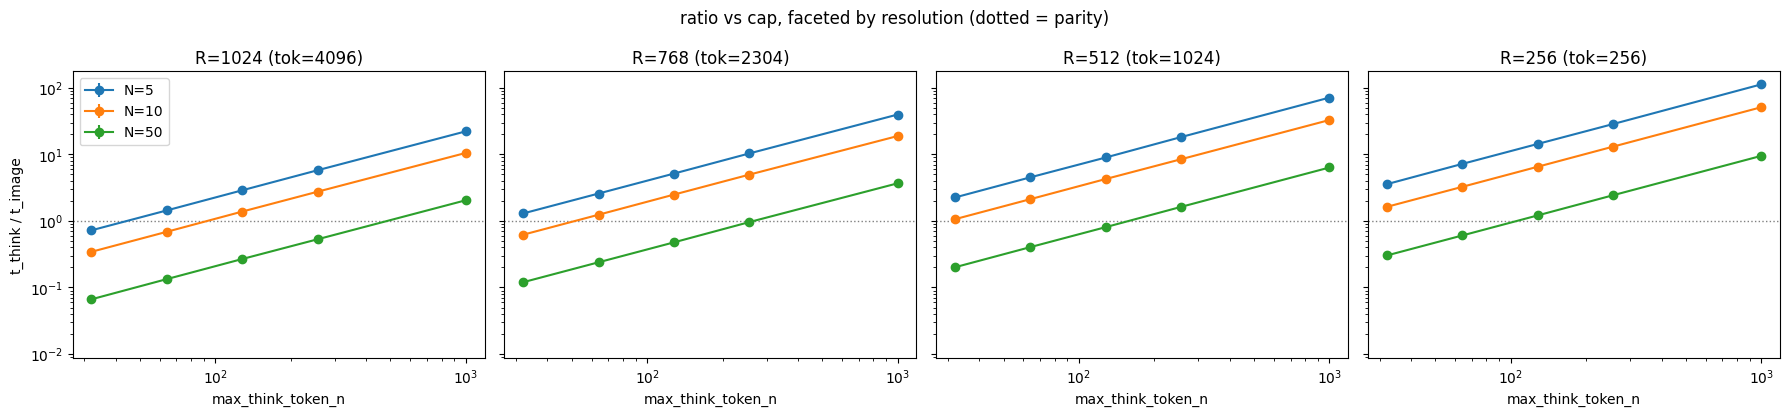

In [16]:
pooled = (
    ok.groupby(["image_side", "num_timesteps", "max_think_token_n"])
    .agg(ratio_mean=("ratio_think_image", "mean"), ratio_std=("ratio_think_image", "std"))
    .reset_index()
)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), sharey=True)
for ax, side in zip(axes, sorted(IMAGE_SIDE_LIST, reverse=True)):
    sub_r = pooled[pooled["image_side"] == side]
    for n in sorted(sub_r["num_timesteps"].unique()):
        sub = sub_r[sub_r["num_timesteps"] == n].sort_values("max_think_token_n")
        ax.errorbar(sub["max_think_token_n"], sub["ratio_mean"], yerr=sub["ratio_std"],
                    marker="o", label=f"N={n}")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"R={side} (tok={(side // LATENT_DOWNSAMPLE) ** 2})")
    ax.set_xlabel("max_think_token_n")
axes[0].set_ylabel("t_think / t_image"); axes[0].legend()
plt.suptitle("ratio vs cap, faceted by resolution (dotted = parity)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ratio_vs_cap_per_R.png"), dpi=150)
plt.show()


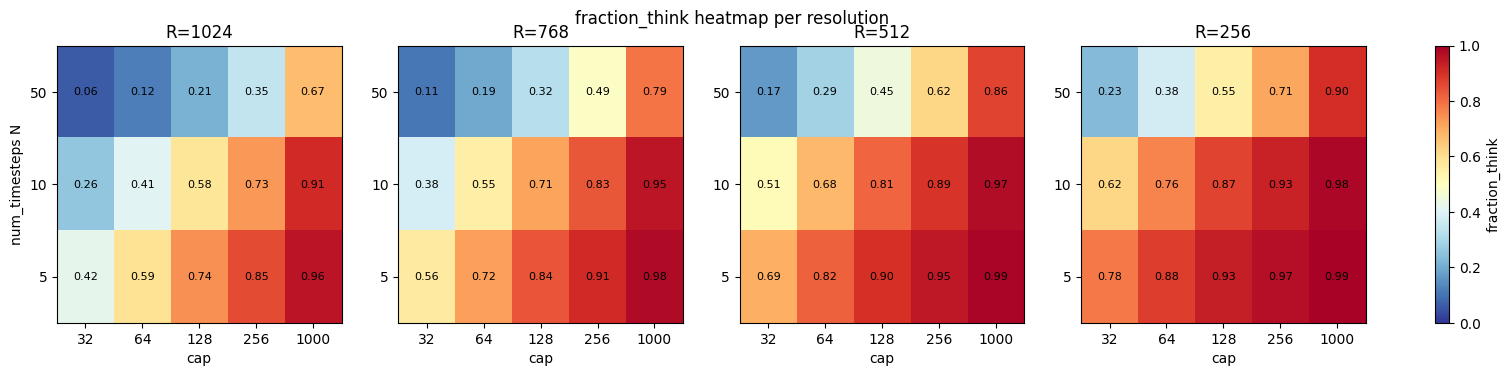

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.6))
for ax, side in zip(axes, sorted(IMAGE_SIDE_LIST, reverse=True)):
    sub = ok[ok["image_side"] == side]
    pivot = sub.pivot_table(index="num_timesteps", columns="max_think_token_n",
                            values="fraction_think", aggfunc="mean")
    pivot = pivot.sort_index(ascending=False)
    im = ax.imshow(pivot.values, cmap="RdYlBu_r", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
    ax.set_xlabel("cap"); ax.set_title(f"R={side}")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
axes[0].set_ylabel("num_timesteps N")
fig.colorbar(im, ax=axes, fraction=0.012, label="fraction_think")
plt.suptitle("fraction_think heatmap per resolution")
plt.savefig(os.path.join(OUTPUT_DIR, "fraction_think_heatmap_per_R.png"),
            dpi=150, bbox_inches="tight")
plt.show()


## 8. H3(自检):`t_think` 应与分辨率无关

t2i 任务 think 阶段没有任何图像输入,分辨率只在 `gen_image` 才生效。
按 cap 分组做 Kruskal-Wallis(跨 4 个 R),**预期全部不显著**;
若显著,说明计时被污染(如 warm-up 不充分、显存碎片影响)。

In [18]:
print(ok.groupby(["max_think_token_n", "image_side"])["t_think"].mean().unstack().round(3))
print()
for cap in sorted(ok["max_think_token_n"].unique()):
    groups = [ok[(ok["max_think_token_n"] == cap) & (ok["image_side"] == side)]["t_think"].values
              for side in IMAGE_SIDE_LIST]
    stat, p = kruskal(*groups)
    flag = "  ← 异常!检查计时" if p < 0.05 else "(不显著,符合预期)"
    print(f"cap={cap:>5}: Kruskal-Wallis H={stat:.3f}, p={p:.4f} {flag}")


image_side           256     512     768     1024
max_think_token_n                                
32                  1.763   1.763   1.762   1.760
64                  3.522   3.522   3.528   3.521
128                 7.060   7.061   7.063   7.068
256                14.075  14.099  14.111  14.052
1000               55.081  54.952  55.051  55.142

cap=   32: Kruskal-Wallis H=1.544, p=0.6722 (不显著,符合预期)
cap=   64: Kruskal-Wallis H=3.482, p=0.3231 (不显著,符合预期)
cap=  128: Kruskal-Wallis H=0.671, p=0.8800 (不显著,符合预期)
cap=  256: Kruskal-Wallis H=9.274, p=0.0259   ← 异常!检查计时
cap= 1000: Kruskal-Wallis H=5.034, p=0.1693 (不显著,符合预期)


## 9. 统计检验:分辨率对 t_image / fraction_think 的效应

配对 Wilcoxon(同一 prompt 在 R=256 vs R=1024 下的均值),每个 N 一组。

## 10. 结论与局限性

**结论**(跑完后按拟合结果填写):

1. H1:`t_image = s(R)·N` 在所有分辨率下均成立(§5 各组 R² = ___)
2. H2:`s(R) = a + b·tok` 中 a = ___ s/step(固定开销),b = ___;二次项 c = ___(显著 / 不显著)
3. H3:t_think 与 R 无关(§8 全部 p > 0.05:是 / 否)
4. 推广的比值定律:`ratio ≈ 0.055·T / ((a + b·tok)·N)`;平衡点 `T*(N, R) = s(R)·N / 0.055`

**局限性**:

- BAGEL 训练分辨率为 1024(`max_latent_size=64` 恰好卡在 64×16),**低分辨率下出图质量
  可能明显下降**——本实验只回答延迟问题,质量成本需要单独的评估实验;
- `s(R)` 的标定只有 4 个点,二次项拟合自由度为 1,attention 是否超线性只能定性判断;
  更严格需要非方形 shape 补点(如 512×1024,tok=2048)验证"成本只由 token 总数决定";
- 2-GPU 流水线(PCIe,无 P2P)会给逐 token 解码引入跨卡通信开销,`t_think` 斜率
  (0.055 s/tok)相对单卡系统偏大,但这不影响 R 维度的结论(think 段与 R 无关);
- cap ∈ {32, 64, 128} 为强截断(hit_cap=100%);cap ∈ {256, 1000} 首跑时为自然长度
  (~160 token,两档等价),已通过 **budget forcing 补跑批次**(§3b,min=max=cap)替换,
  使 think 长度精确钉在 cap 上。注意强制批次是"EOS→' Wait,'"诱导的续写,内容上有重复
  ("车轱辘话"),对延迟测量无影响,但强制/自然两种 think 不能混同比较质量;
- 截断与强制续写对图像质量的影响均不在本实验范围内。


## 10. 结论与局限性

**结论**(跑完后按拟合结果填写):

1. H1:`t_image = s(R)·N` 在所有分辨率下均成立(§5 各组 R² = ___)
2. H2:`s(R) = a + b·tok` 中 a = ___ s/step(固定开销),b = ___;二次项 c = ___(显著 / 不显著)
3. H3:t_think 与 R 无关(§8 全部 p > 0.05:是 / 否)
4. 推广的比值定律:`ratio ≈ 0.055·T / ((a + b·tok)·N)`;平衡点 `T*(N, R) = s(R)·N / 0.055`

**局限性**:

- BAGEL 训练分辨率为 1024(`max_latent_size=64` 恰好卡在 64×16),**低分辨率下出图质量
  可能明显下降**——本实验只回答延迟问题,质量成本需要单独的评估实验;
- `s(R)` 的标定只有 4 个点,二次项拟合自由度为 1,attention 是否超线性只能定性判断;
  更严格需要非方形 shape 补点(如 512×1024,tok=2048)验证"成本只由 token 总数决定";
- 2-GPU 流水线(PCIe,无 P2P)会给逐 token 解码引入跨卡通信开销,`t_think` 斜率
  (0.055 s/tok)相对单卡系统偏大,但这不影响 R 维度的结论(think 段与 R 无关);
- cap ∈ {32, 64, 128} 为强截断(hit_cap=100%),cap ∈ {256, 1000} 为自然长度(~160 tok),
  与上一实验相同,截断对图像质量的影响不在本实验范围内。
